### Black Hat Morphological Operation

The Black Hat operation is a morphological transformation that highlights small, dark elements on a bright background. It is defined as the difference between the **closing** of an image and the original image itself.

Mathematically, for an image $f$ and a structuring element $b$:

$BlackHat(f) = Closing(f) - f$

Where $Closing(f) = (f \oplus b) \ominus b$ (dilation followed by erosion).

In simpler terms, it helps to find "holes" or "gaps" that are smaller than the structuring element and darker than the surrounding features. While not directly a 'dilation of foreground regions' in the conventional sense, it can effectively isolate dark foreground features by subtracting them from a 'smoothed' version of the image.

Let's apply this operation using OpenCV.

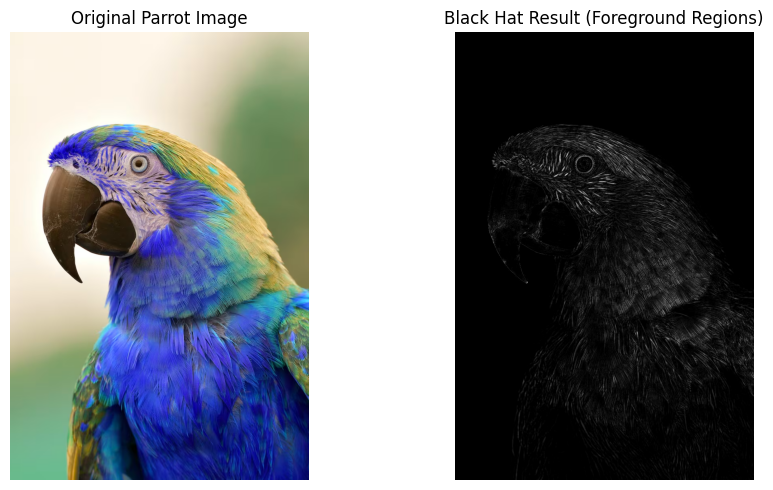

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the parrot image
image_path = '/content/parrot image.avif'
image_color = cv2.imread(image_path)

# Check if image was loaded successfully
if image_color is None:
    print(f"Error: Could not load image from {image_path}")
else:
    # Convert the image to grayscale
    image = cv2.cvtColor(image_color, cv2.COLOR_BGR2GRAY)

    # Display the original image
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image_color) # Display original color image
    plt.title('Original Parrot Image')
    plt.axis('off')

    # Define a structuring element (kernel)
    # A 5x5 rectangular kernel is common for many applications
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

    # Apply the Black Hat operation
    blackhat = cv2.morphologyEx(image, cv2.MORPH_BLACKHAT, kernel)

    # Display the result
    plt.subplot(1, 2, 2)
    plt.imshow(blackhat, cmap='gray')
    plt.title('Black Hat Result (Foreground Regions)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()